# IPL 2022 Data Analysis

Exploratory Data Analysis of IPL 2022 dataset using Python, Pandas, Matplotlib and Seaborn to uncover insights about team performance, player achievements and match trends.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('IPL.csv')
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


BASIC INFORAMATION

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

check the size of rows and columns of dataset

In [4]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


Now let's see how many columns have null values in total.

In [5]:
df.isnull().sum() #zero null values

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

1. Which team won the most matches?

In [6]:
match_wins=df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

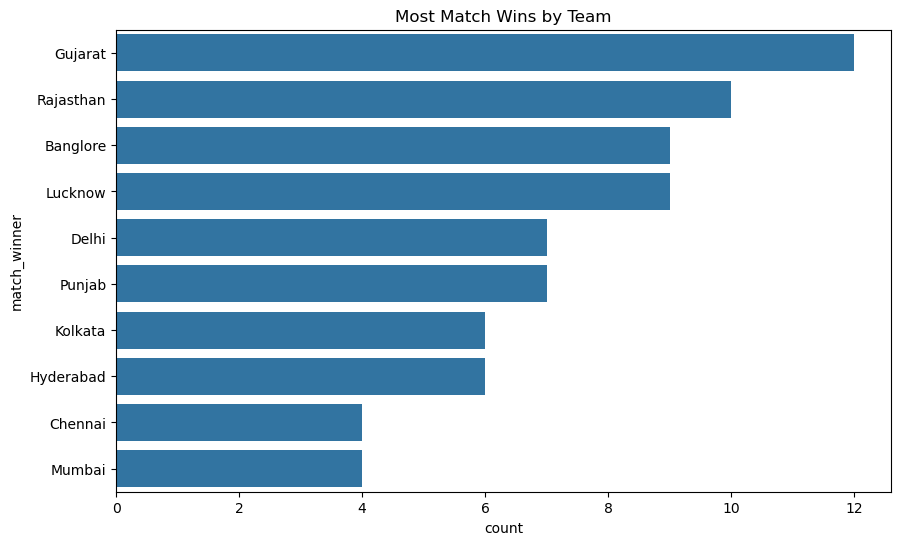

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(y='match_winner',data=df,order=df['match_winner'].value_counts().index)
plt.title("Most Match Wins by Team")
plt.savefig("team_wins.png")

2.Toss Decision Trends

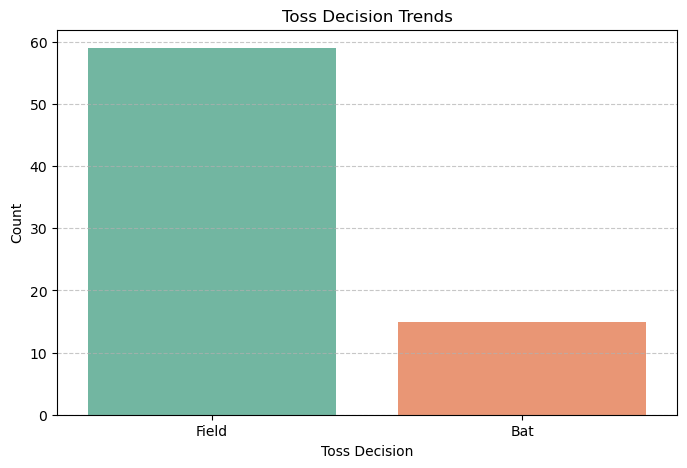

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='toss_decision',
    data=df,
    palette='Set2'
)

plt.title("Toss Decision Trends")
plt.xlabel("Toss Decision")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("toss_decision.png", bbox_inches="tight")

plt.show()

3.Toss Winner vs Match Winner

In [9]:
count = (df['toss_winner'] == df['match_winner']).sum()
print("count",count)
percentage = round((count*100)/len(df),2)
print("percentage",percentage)

count 36
percentage 48.65


4.How do teams win? (Runs vs Wickets)

In [10]:
wicket=(df["won_by"]=='Wickets').sum()
percentage_w=(wicket*100)/len(df)
print('won by wicket',percentage_w)

won by wicket 50.0


Text(0.5, 1.0, 'WON BY')

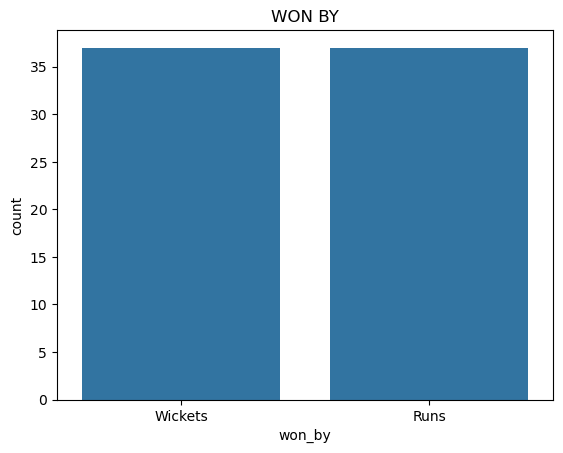

In [11]:
sns.countplot(x='won_by',data=df)
plt.title("WON BY")

Key Player Performances

1.Most "Player of the Match" Awards

In [12]:
player=df['player_of_the_match'].value_counts().head(10)
print(f"player name {player.idxmax()} got most award: {player.max()}")

player name Kuldeep Yadav got most award: 4


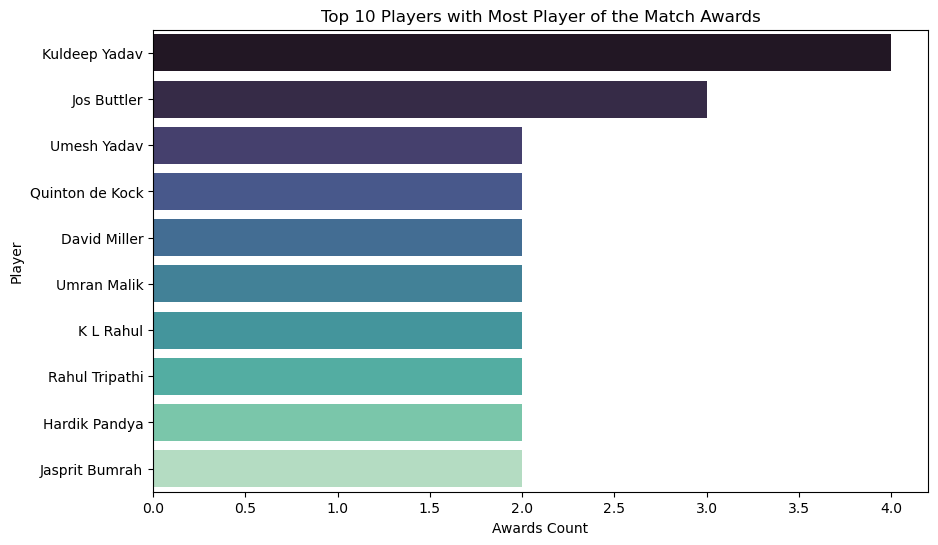

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=player.values,
    y=player.index,
    palette="mako"
)

plt.title("Top 10 Players with Most Player of the Match Awards")
plt.xlabel("Awards Count")
plt.ylabel("Player")
plt.savefig("man_of_match.png", bbox_inches="tight")
plt.show()

2 Top Scorers

In [14]:
top2 = df.nlargest(2, 'highscore')[['top_scorer','highscore']]
print(top2)

         top_scorer  highscore
65  Quinton de Kock        140
33      Jos Buttler        116


In [15]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


10 best Bowling figure

In [16]:
df[['wickets','runs']] = df['best_bowling_figure'].str.split('--',expand=True).astype(int)

top10 = df.sort_values(['wickets','runs'],ascending=[False,True]).head(10)

print(top10[['best_bowling','best_bowling_figure']])

         best_bowling best_bowling_figure
55     Jasprit Bumrah               5--10
53  Wanindu Hasaranga               5--18
39        Umran Malik               5--25
29   Yuzvendra Chahal               5--40
34      Andre Russell                4--5
40      Kuldeep Yadav               4--14
44        Mohsin Khan               4--16
5   Wanindu Hasaranga               4--20
38        Kuldeep Sen               4--20
7         Umesh Yadav               4--23


Venue Analysis

Most Matches Played by Venue

In [17]:
venue_count = df['venue'].value_counts()
venue_count


venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

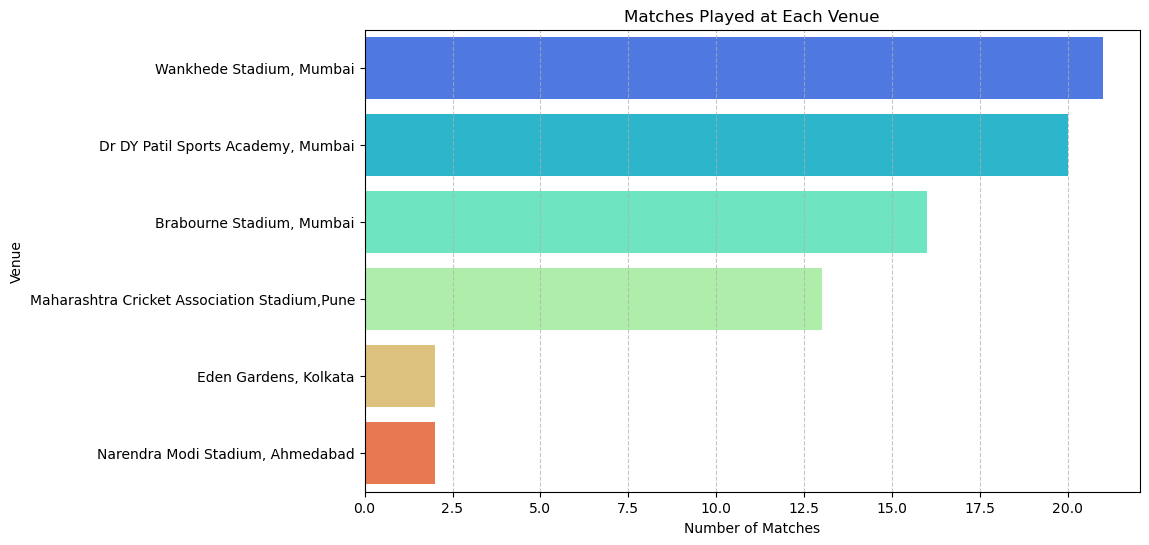

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    y=venue_count.index,
    x=venue_count.values,
    palette="rainbow"
)

plt.title("Matches Played at Each Venue")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig("venue_matches.png", bbox_inches="tight")

plt.show()

Custom Questions & Insights

Q1: Who won the highest margin by runs?

In [19]:
wonby_run=df[df['won_by']=='Runs']
wonby_run.nlargest(1,'margin')[['match_winner','margin']]


,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

In [20]:
df.nlargest(1,"highscore")['top_scorer']

65    Quinton de Kock
Name: top_scorer, dtype: object

Q3: Which bowler had the best bowling figures?

In [21]:
top=df.sort_values(['wickets','runs'],ascending=[False,True]).head(1)
top[['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10
